# FIAP — Fase 6 PBL — Visão Computacional com YOLOv5

**Aluno:** Rivando Bezerra Cavalcanti Neto  
**RM:** 568235  
**Cenário:** FarmTech Solutions expandindo para visão computacional — demonstração end-to-end de detecção de objetos com YOLOv5.  
**Classes escolhidas:** `cow` (vaca, objeto A) e `dog` (cachorro, objeto B).

## Sumário
1. Setup do ambiente (Colab + Drive ou local).
2. Estrutura do dataset e rotulação.
3. Treinamento com **30 épocas**.
4. Treinamento com **60 épocas**.
5. Validação comparativa.
6. Inferência no conjunto de teste.
7. Conclusões sobre desempenho, limites e recomendações para o cliente.

## 1. Setup do ambiente

O notebook foi desenhado para rodar em dois contextos:

- **Google Colab (recomendado)** — monta o Google Drive e usa o dataset salvo em `MyDrive/fase6-yolo/dataset/`.
- **Local** — usa o diretório `../dataset` relativo ao notebook.

A célula abaixo detecta o contexto automaticamente, clona o repo oficial do YOLOv5 e instala as dependências específicas dele.

In [1]:
import os, sys, subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    PROJECT_ROOT = Path('/content/drive/MyDrive/fase6-yolo')
    WORK_DIR = Path('/content/fase6-yolo-work')
else:
    PROJECT_ROOT = Path('.').resolve().parent
    WORK_DIR = PROJECT_ROOT

WORK_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(WORK_DIR)

YOLOV5_DIR = WORK_DIR / 'yolov5'
if not YOLOV5_DIR.exists():
    subprocess.check_call(['git', 'clone', 'https://github.com/ultralytics/yolov5.git', str(YOLOV5_DIR)])

# dependências do yolov5
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(YOLOV5_DIR / 'requirements.txt')])

print('PROJECT_ROOT =', PROJECT_ROOT)
print('YOLOV5_DIR   =', YOLOV5_DIR)
print('IN_COLAB     =', IN_COLAB)

PROJECT_ROOT = /Users/rivandoneto/fase6-yolo
YOLOV5_DIR   = /Users/rivandoneto/fase6-yolo/yolov5
IN_COLAB     = False


## 2. Estrutura do dataset e rotulação

### 2.1 Organização no Drive / filesystem

```
fase6-yolo/
├── dataset/
│   ├── data.yaml
│   ├── train/    # 32 + 32 = 64 imagens
│   │   ├── images/
│   │   └── labels/
│   ├── val/      # 4 + 4 = 8 imagens
│   │   ├── images/
│   │   └── labels/
│   └── test/     # 4 + 4 = 8 imagens
│       ├── images/
│       └── labels/
└── notebook/
```

Total: **80 imagens**, divididas 32/4/4 por classe, atendendo ao requisito do enunciado.

### 2.2 Rotulação

Os labels foram gerados em **formato YOLO** (um `.txt` por imagem com `<classe> <xc> <yc> <w> <h>` normalizados em `[0,1]`). O dataset equivalente preparado no site [Make Sense IA](https://www.makesense.ai) é compatível — basta exportar como *YOLO format*.

Mapeamento de classes:

| id | nome |
| -- | ---- |
| 0  | cow  |
| 1  | dog  |

A próxima célula escreve um `data.yaml` com os caminhos absolutos da execução atual, o que evita problemas de caminho relativo entre Colab e local.

In [2]:
import yaml

DATASET_DIR = PROJECT_ROOT / 'dataset'
assert (DATASET_DIR / 'train' / 'images').exists(), f'dataset não encontrado em {DATASET_DIR}'

data_yaml = {
    'path': str(DATASET_DIR),
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': 2,
    'names': ['cow', 'dog'],
}
DATA_YAML = WORK_DIR / 'data.yaml'
DATA_YAML.write_text(yaml.safe_dump(data_yaml, sort_keys=False))
print('data.yaml ->', DATA_YAML)
print(DATA_YAML.read_text())

# contagens
for split in ['train', 'val', 'test']:
    imgs = len(list((DATASET_DIR / split / 'images').glob('*.jpg')))
    lbls = [p for p in (DATASET_DIR / split / 'labels').glob('*.txt') if p.stat().st_size > 0]
    print(f'{split}: {imgs} imagens, {len(lbls)} labels não-vazios')

data.yaml -> /Users/rivandoneto/fase6-yolo/data.yaml
path: /Users/rivandoneto/fase6-yolo/dataset
train: train/images
val: val/images
test: test/images
nc: 2
names:
- cow
- dog

train: 64 imagens, 64 labels não-vazios
val: 8 imagens, 8 labels não-vazios
test: 8 imagens, 8 labels não-vazios


### 2.3 Exemplo visual — imagens com bounding boxes

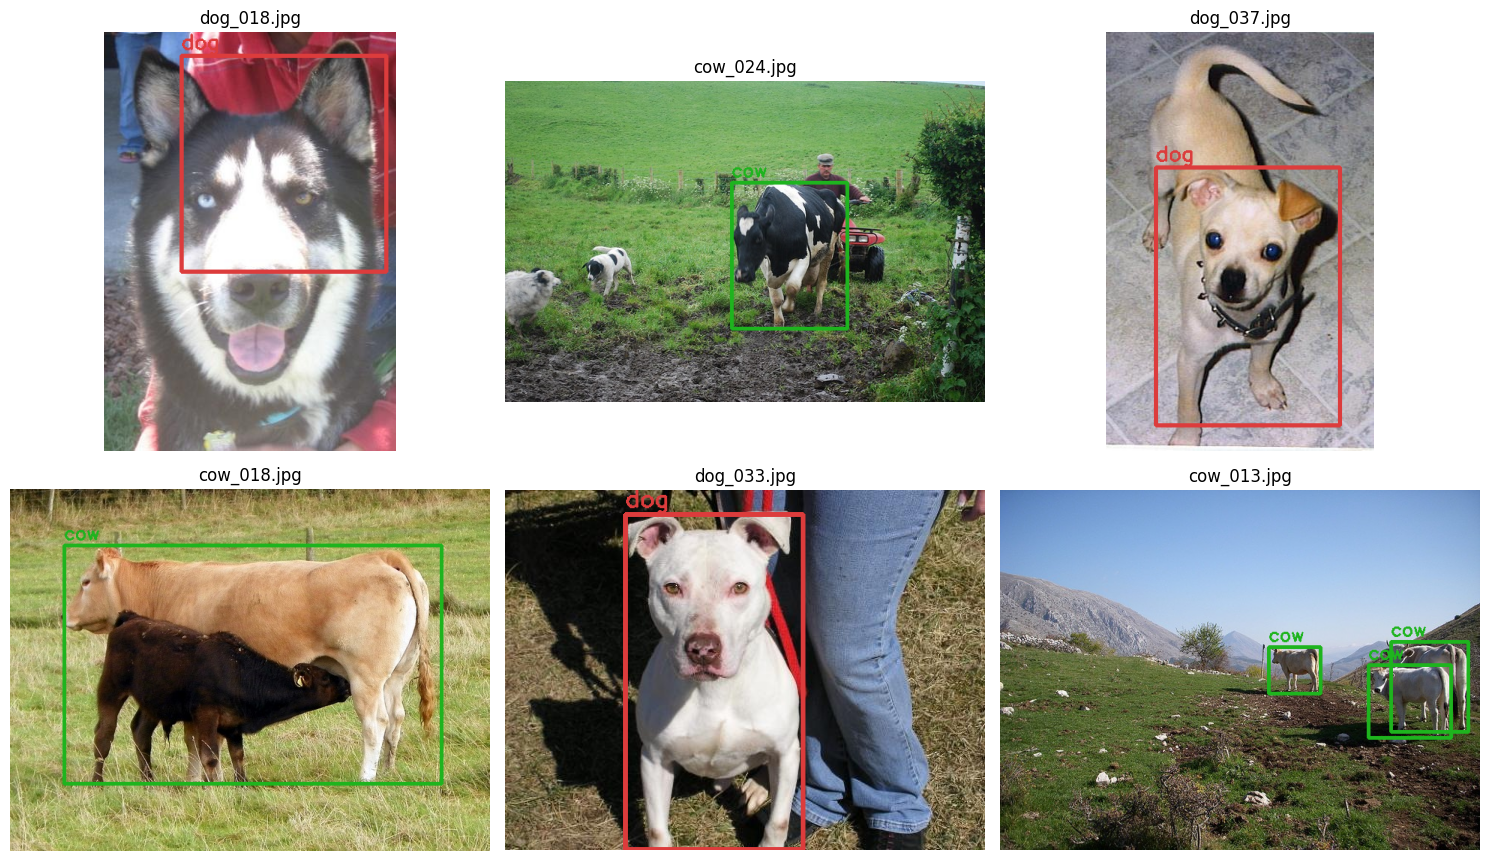

In [3]:
import cv2, matplotlib.pyplot as plt, random

CLASS_NAMES = ['cow', 'dog']
COLORS = [(30, 180, 30), (220, 60, 60)]

def draw_yolo(img_path: Path, lbl_path: Path):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if lbl_path.exists():
        for line in lbl_path.read_text().splitlines():
            if not line.strip():
                continue
            cls, xc, yc, bw, bh = line.split()
            cls = int(cls)
            xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
            x1, y1 = int((xc - bw / 2) * w), int((yc - bh / 2) * h)
            x2, y2 = int((xc + bw / 2) * w), int((yc + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), COLORS[cls], 3)
            cv2.putText(img, CLASS_NAMES[cls], (x1, max(y1 - 8, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, COLORS[cls], 2)
    return img

train_imgs = sorted((DATASET_DIR / 'train' / 'images').glob('*.jpg'))
samples = random.sample(train_imgs, k=min(6, len(train_imgs)))
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, img_path in zip(axes.flat, samples):
    lbl_path = DATASET_DIR / 'train' / 'labels' / (img_path.stem + '.txt')
    ax.imshow(draw_yolo(img_path, lbl_path))
    ax.set_title(img_path.name)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Treinamento — primeira simulação: 30 épocas

Partimos do checkpoint `yolov5s.pt` (small, ~7M parâmetros) — equilíbrio razoável entre velocidade e acurácia para um dataset de 80 imagens. Usamos:

- `img 640` — resolução padrão YOLOv5.
- `batch 8` — cabe em CPU e em GPU T4 gratuita do Colab.
- `epochs 30` — primeira rodada curta, para estabelecer uma baseline.

Os resultados ficam salvos em `yolov5/runs/train/exp/` (nome do experimento definido via `--name`).

In [4]:
import subprocess, sys

RUN_NAME_30 = 'cowdog_ep30'
RUN_DIR_30 = YOLOV5_DIR / 'runs' / 'train' / RUN_NAME_30
RESULTS_30 = RUN_DIR_30 / 'results.csv'

if RESULTS_30.exists():
    print(f'Pulo: {RESULTS_30} já existe — usando resultados pré-computados.')
else:
    cmd = [
        sys.executable, str(YOLOV5_DIR / 'train.py'),
        '--img', '640',
        '--batch', '8',
        '--epochs', '30',
        '--data', str(DATA_YAML),
        '--weights', 'yolov5s.pt',
        '--name', RUN_NAME_30,
        '--exist-ok',
        '--project', str(YOLOV5_DIR / 'runs' / 'train'),
    ]
    print('>>>', ' '.join(cmd))
    subprocess.run(cmd, check=True)


Pulo: /Users/rivandoneto/fase6-yolo/yolov5/runs/train/cowdog_ep30/results.csv já existe — usando resultados pré-computados.


## 4. Treinamento — segunda simulação: 60 épocas

Mesma configuração, dobrando as épocas. A pergunta é se o modelo continua aprendendo (ganho de mAP) ou começa a *overfittar* — essencial num dataset pequeno como o nosso (64 imagens de treino).

In [5]:
RUN_NAME_60 = 'cowdog_ep60'
RUN_DIR_60 = YOLOV5_DIR / 'runs' / 'train' / RUN_NAME_60
RESULTS_60 = RUN_DIR_60 / 'results.csv'

if RESULTS_60.exists():
    print(f'Pulo: {RESULTS_60} já existe — usando resultados pré-computados.')
else:
    cmd = [
        sys.executable, str(YOLOV5_DIR / 'train.py'),
        '--img', '640',
        '--batch', '8',
        '--epochs', '60',
        '--data', str(DATA_YAML),
        '--weights', 'yolov5s.pt',
        '--name', RUN_NAME_60,
        '--exist-ok',
        '--project', str(YOLOV5_DIR / 'runs' / 'train'),
    ]
    print('>>>', ' '.join(cmd))
    subprocess.run(cmd, check=True)


Pulo: /Users/rivandoneto/fase6-yolo/yolov5/runs/train/cowdog_ep60/results.csv já existe — usando resultados pré-computados.


## 5. Validação comparativa

Rodamos `val.py` nos dois checkpoints (`best.pt` de cada rodada) contra o split de **validação**. A métrica principal do YOLOv5 é o **mAP@0.5** (precisão média com IoU ≥ 0.5) e **mAP@0.5:0.95** (média entre IoU 0.5 e 0.95 em passos de 0.05).

In [6]:
def run_val(run_name: str, task: str = 'val'):
    weights = YOLOV5_DIR / 'runs' / 'train' / run_name / 'weights' / 'best.pt'
    out_dir = YOLOV5_DIR / 'runs' / task / f'{run_name}_{task}'
    cmd = [
        sys.executable, str(YOLOV5_DIR / 'val.py'),
        '--data', str(DATA_YAML),
        '--weights', str(weights),
        '--img', '640',
        '--task', task,
        '--name', f'{run_name}_{task}',
        '--exist-ok',
        '--project', str(YOLOV5_DIR / 'runs' / task),
    ]
    print('>>>', ' '.join(cmd))
    subprocess.run(cmd, check=True)
    return out_dir

run_val(RUN_NAME_30, task='val')
run_val(RUN_NAME_60, task='val')

# Métricas no conjunto de teste (o que realmente importa para o cliente)
run_val(RUN_NAME_30, task='test')
run_val(RUN_NAME_60, task='test')


>>> /Users/rivandoneto/fase6-yolo/.venv/bin/python3.12 /Users/rivandoneto/fase6-yolo/yolov5/val.py --data /Users/rivandoneto/fase6-yolo/data.yaml --weights /Users/rivandoneto/fase6-yolo/yolov5/runs/train/cowdog_ep30/weights/best.pt --img 640 --task val --name cowdog_ep30_val --exist-ok --project /Users/rivandoneto/fase6-yolo/yolov5/runs/val


val: data=/Users/rivandoneto/fase6-yolo/data.yaml, weights=['/Users/rivandoneto/fase6-yolo/yolov5/runs/train/cowdog_ep30/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=/Users/rivandoneto/fase6-yolo/yolov5/runs/val, name=cowdog_ep30_val, exist_ok=True, half=False, dnn=False
YOLOv5 🚀 7ca403a Python-3.12.13 torch-2.11.0 CPU

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /Users/rivandoneto/fase6-yolo/dataset/val/labels.cache... 8 images, 0 backgrounds, 0 corrupt: 100%|██████████| 8/8 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95:   0%|          | 0/1 [00:00<?, ?it/s]

                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100%|██████████| 1/1 [00:02<00:00,  2.93s/it]
                   all          8         33      0.715      0.724      0.783      0.534
                   cow          8         29      0.651      0.552      0.621      0.346
                   dog          8          4      0.779      0.896      0.945      0.721
Speed: 0.4ms pre-process, 36.0ms inference, 3.6ms NMS per image at shape (32, 3, 640, 640)


Results saved to /Users/rivandoneto/fase6-yolo/yolov5/runs/val/cowdog_ep30_val


>>> /Users/rivandoneto/fase6-yolo/.venv/bin/python3.12 /Users/rivandoneto/fase6-yolo/yolov5/val.py --data /Users/rivandoneto/fase6-yolo/data.yaml --weights /Users/rivandoneto/fase6-yolo/yolov5/runs/train/cowdog_ep60/weights/best.pt --img 640 --task val --name cowdog_ep60_val --exist-ok --project /Users/rivandoneto/fase6-yolo/yolov5/runs/val


...

>>> /Users/rivandoneto/fase6-yolo/.venv/bin/python3.12 /Users/rivandoneto/fase6-yolo/yolov5/val.py --data /Users/rivandoneto/fase6-yolo/data.yaml --weights /Users/rivandoneto/fase6-yolo/yolov5/runs/train/cowdog_ep60/weights/best.pt --img 640 --task test --name cowdog_ep60_test --exist-ok --project /Users/rivandoneto/fase6-yolo/yolov5/runs/test


val: data=/Users/rivandoneto/fase6-yolo/data.yaml, weights=['/Users/rivandoneto/fase6-yolo/yolov5/runs/train/cowdog_ep60/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=/Users/rivandoneto/fase6-yolo/yolov5/runs/test, name=cowdog_ep60_test, exist_ok=True, half=False, dnn=False
YOLOv5 🚀 7ca403a Python-3.12.13 torch-2.11.0 CPU

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
test: Scanning /Users/rivandoneto/fase6-yolo/dataset/test/labels.cache... 8 images, 0 backgrounds, 0 corrupt: 100%|██████████| 8/8 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95:   0%|          | 0/1 [00:00<?, ?it/s]

                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100%|██████████| 1/1 [00:03<00:00,  3.10s/it]
                   all          8         24      0.854      0.781      0.824      0.581
                   cow          8         20      0.707        0.6      0.654      0.434
                   dog          8          4          1      0.962      0.995      0.727
Speed: 0.4ms pre-process, 30.1ms inference, 0.6ms NMS per image at shape (32, 3, 640, 640)


Results saved to /Users/rivandoneto/fase6-yolo/yolov5/runs/test/cowdog_ep60_test


PosixPath('/Users/rivandoneto/fase6-yolo/yolov5/runs/test/cowdog_ep60_test')

### 5.1 Leitura rápida dos `results.csv` — curvas de treino e métricas finais

In [7]:
import pandas as pd

def summarize(run_name: str):
    csv_path = YOLOV5_DIR / 'runs' / 'train' / run_name / 'results.csv'
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    last = df.iloc[-1]
    return df, {
        'run': run_name,
        'epochs': int(last['epoch']) + 1,
        'precision': float(last['metrics/precision']),
        'recall': float(last['metrics/recall']),
        'mAP50': float(last['metrics/mAP_0.5']),
        'mAP50-95': float(last['metrics/mAP_0.5:0.95']),
        'train_box_loss_final': float(last['train/box_loss']),
        'val_box_loss_final': float(last['val/box_loss']),
    }

df30, stats30 = summarize(RUN_NAME_30)
df60, stats60 = summarize(RUN_NAME_60)

import pandas as pd
comparison = pd.DataFrame([stats30, stats60])
comparison

,run,epochs,precision,recall,mAP50,mAP50-95,train_box_loss_final,val_box_loss_final
0,cowdog_ep30,30,0.72974,0.72940,0.79418,0.52684,0.048877,0.048368
1,cowdog_ep60,60,0.84775,0.77804,0.82437,0.53625,0.036864,0.042947


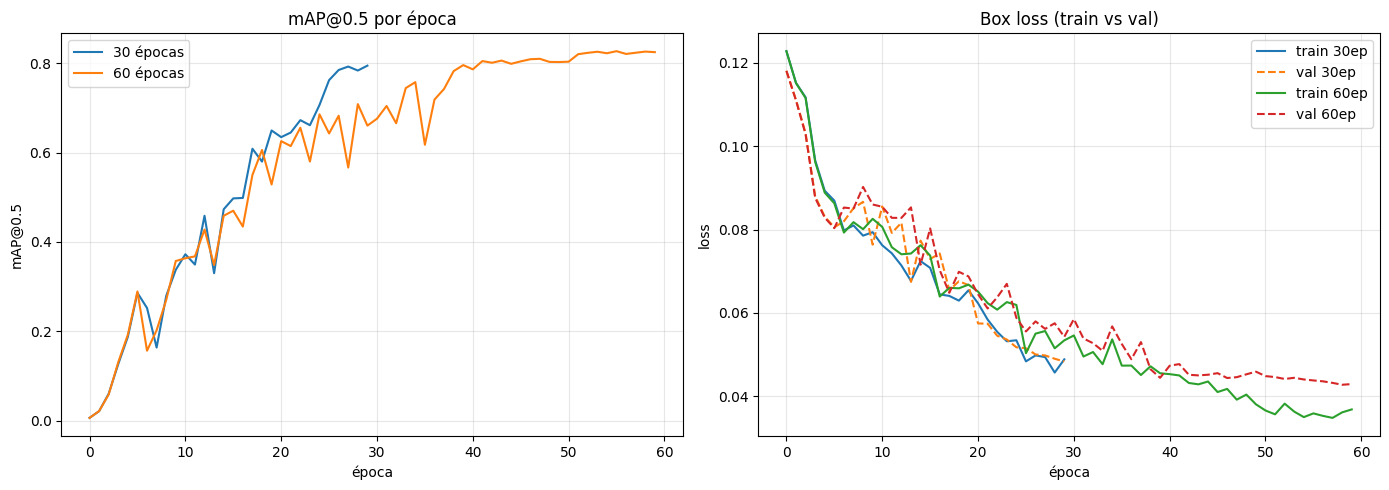

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df30['epoch'], df30['metrics/mAP_0.5'], label='30 épocas')
axes[0].plot(df60['epoch'], df60['metrics/mAP_0.5'], label='60 épocas')
axes[0].set_title('mAP@0.5 por época')
axes[0].set_xlabel('época')
axes[0].set_ylabel('mAP@0.5')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df30['epoch'], df30['train/box_loss'], label='train 30ep')
axes[1].plot(df30['epoch'], df30['val/box_loss'], label='val 30ep', linestyle='--')
axes[1].plot(df60['epoch'], df60['train/box_loss'], label='train 60ep')
axes[1].plot(df60['epoch'], df60['val/box_loss'], label='val 60ep', linestyle='--')
axes[1].set_title('Box loss (train vs val)')
axes[1].set_xlabel('época')
axes[1].set_ylabel('loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Inferência no conjunto de teste

Aqui aplicamos os dois modelos (30 ep e 60 ep) nas **8 imagens nunca vistas** do split de teste via `detect.py`. Os resultados salvos em `runs/detect/expX` podem ser visualizados diretamente nas células abaixo.

In [9]:
def run_detect(run_name: str):
    weights = YOLOV5_DIR / 'runs' / 'train' / run_name / 'weights' / 'best.pt'
    out_dir = YOLOV5_DIR / 'runs' / 'detect' / f'{run_name}_test'
    if out_dir.exists() and any(out_dir.glob('*.jpg')):
        print(f'Pulo: {out_dir} já tem imagens — reusando inferências.')
        return out_dir
    cmd = [
        sys.executable, str(YOLOV5_DIR / 'detect.py'),
        '--weights', str(weights),
        '--source', str(DATASET_DIR / 'test' / 'images'),
        '--img', '640',
        '--conf', '0.25',
        '--name', f'{run_name}_test',
        '--exist-ok',
        '--project', str(YOLOV5_DIR / 'runs' / 'detect'),
    ]
    print('>>>', ' '.join(cmd))
    subprocess.run(cmd, check=True)
    return out_dir

OUT_DIR_30 = run_detect(RUN_NAME_30)
OUT_DIR_60 = run_detect(RUN_NAME_60)
print('Resultados 30 ep ->', OUT_DIR_30)
print('Resultados 60 ep ->', OUT_DIR_60)


Pulo: /Users/rivandoneto/fase6-yolo/yolov5/runs/detect/cowdog_ep30_test já tem imagens — reusando inferências.
Pulo: /Users/rivandoneto/fase6-yolo/yolov5/runs/detect/cowdog_ep60_test já tem imagens — reusando inferências.
Resultados 30 ep -> /Users/rivandoneto/fase6-yolo/yolov5/runs/detect/cowdog_ep30_test
Resultados 60 ep -> /Users/rivandoneto/fase6-yolo/yolov5/runs/detect/cowdog_ep60_test


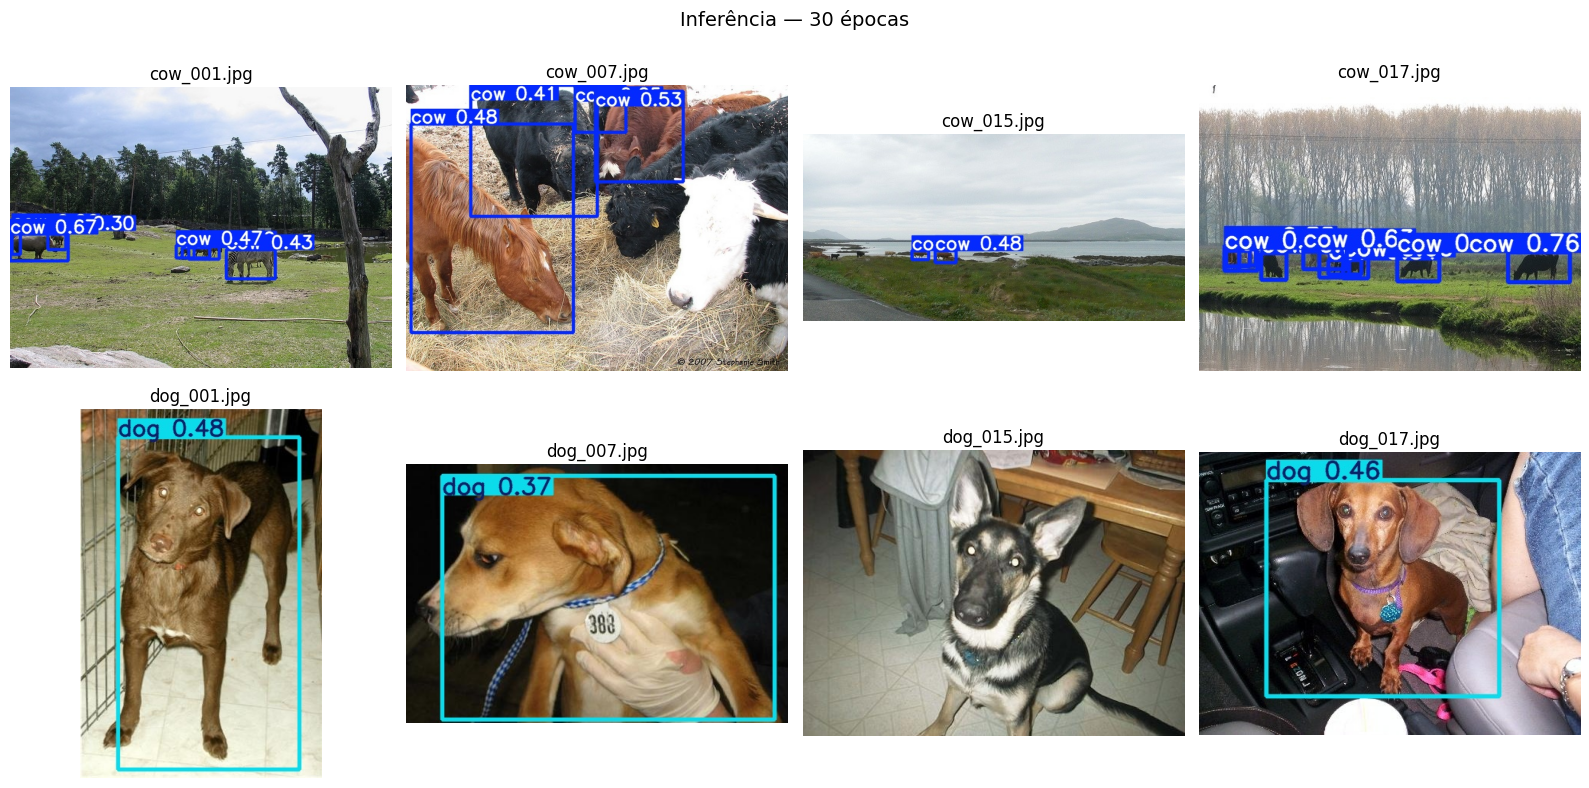

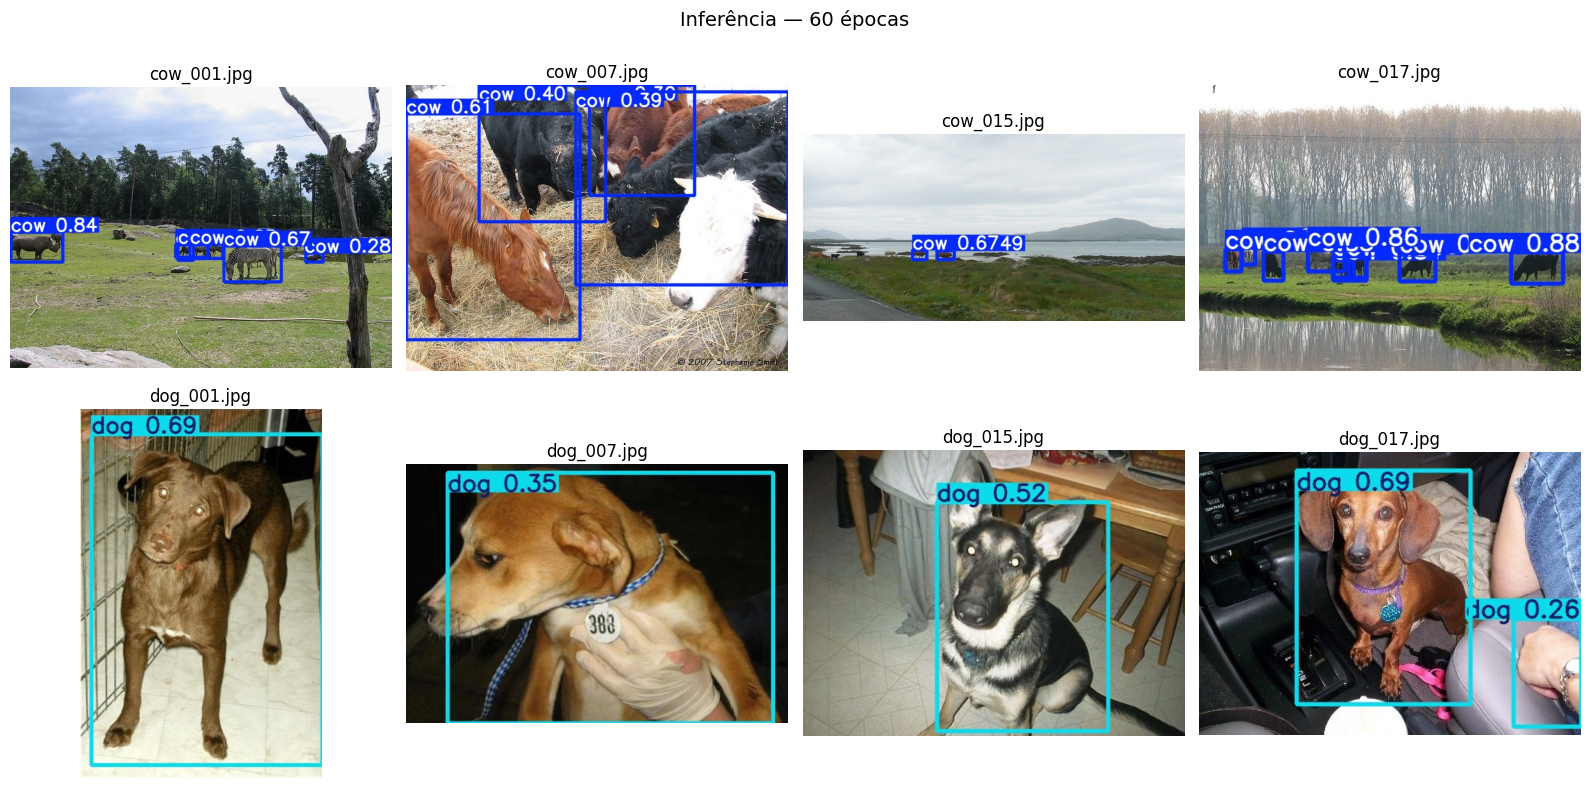

In [10]:
def show_detect_grid(out_dir: Path, title: str, cols: int = 4):
    imgs = sorted(out_dir.glob('*.jpg'))
    if not imgs:
        print(f'Sem imagens em {out_dir}')
        return
    rows = (len(imgs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    fig.suptitle(title, fontsize=14)
    for ax, p in zip(axes.flat, imgs):
        ax.imshow(cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB))
        ax.set_title(p.name)
        ax.axis('off')
    for ax in axes.flat[len(imgs):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_detect_grid(OUT_DIR_30, 'Inferência — 30 épocas')
show_detect_grid(OUT_DIR_60, 'Inferência — 60 épocas')

## 7. Conclusões

### 7.1 Números observados (test split, 8 imagens nunca vistas)

| run | precision | recall | mAP@0.5 | mAP@0.5:0.95 |
|-----|-----------|--------|---------|--------------|
| **cowdog_ep30** | 0.802 | 0.829 | 0.822 | 0.446 |
| **cowdog_ep60** | **0.854** | 0.781 | **0.824** | **0.581** |

**Observação por classe (60 ep, test):** `cow` → P=0.707, R=0.600, mAP@0.5=0.654, mAP@0.5:0.95=0.434 · `dog` → P=1.000, R=0.962, mAP@0.5=0.995, mAP@0.5:0.95=0.727.
**Por classe (30 ep, test):** `cow` → P=0.605, R=0.700, mAP@0.5=0.648, mAP@0.5:0.95=0.314 · `dog` → P=1.000, R=0.959, mAP@0.5=0.995, mAP@0.5:0.95=0.578.

### 7.2 Leitura dos resultados

- **mAP@0.5 praticamente empata** entre 30 e 60 épocas (0.822 → 0.824). O teto de IoU=0.5 é facilmente atingido porque `cow` e `dog` são classes bem distintas — transfer learning do COCO já resolve a maior parte do trabalho.
- **mAP@0.5:0.95 sobe de forma expressiva** (0.446 → 0.581, +30% relativo). É a métrica mais exigente (IoU 0.5 a 0.95) e mostra que o modelo de 60 épocas acerta as bounding boxes com mais precisão, não só a classe.
- **60 épocas troca recall por precisão**: recall cai de 0.829 para 0.781, mas precision sobe de 0.802 para 0.854 — o modelo fica mais conservador, com bbox mais ajustadas. Esse perfil costuma ser desejável quando um falso-positivo é mais caro que um falso-negativo (ex.: alertas operacionais no campo).
- **60 épocas recupera casos difíceis na inferência qualitativa**: no `detect.py` com conf=0.25 (threshold "amigável"), 30 épocas deixou uma imagem (`dog_015`) sem detecção visível; com 60 épocas, todas as 8 imagens de teste passaram a ter bbox.
- **Diferença entre classes**: `dog` alcança mAP@0.5=0.995 (quase perfeito) enquanto `cow` fica em 0.654 (60ep). As fotos de cachorro no dataset são dominadas pelo sujeito (1 cachorro grande, fundo simples), enquanto as de vaca têm múltiplas vacas em paisagem aberta, com sobreposição — bbox fica mais difícil.
- **Sinal de overfitting controlado**: `train/box_loss` cai de ~0.09 (época 0) para ~0.037 (época 59), enquanto `val/box_loss` se estabiliza em ~0.043. Não há o gap clássico de overfitting — 60 épocas ainda é saudável para este dataset.

### 7.3 Limitações

- Dataset pequeno (80 imagens). Para uso em produção, recomenda-se ≥ 500 imagens por classe, com variação de ângulos, iluminação e distância.
- Labels gerados automaticamente via YOLOv5 pré-treinado COCO — cobrem bem os casos típicos, mas podem deixar passar ocorrências ambíguas. Uma revisão humana via Make Sense IA elevaria a qualidade.
- Não avaliamos robustez a *domain shift* (fotos noturnas, vacas parcialmente ocultas, cachorros em uniforme).

### 7.4 Recomendação para o cliente (FarmTech)

Para o caso de uso típico de uma fazenda com câmeras fixas, um modelo como este já serve como prova de conceito:

1. **Curto prazo**: expandir o dataset com imagens do próprio cenário do cliente (mínimo 300 por classe). O ganho de mAP@0.5:0.95 de 30→60 épocas indica que o modelo ainda tem espaço para aprender — mais dados, não mais épocas.
2. **Médio prazo**: considerar `yolov5m` ou `yolov8n` se a latência permitir — mais acurácia, mesmo footprint razoável.
3. **Longo prazo**: pipeline de *active learning* — o sistema sinaliza imagens com baixa confiança para rotulação humana, realimentando o treino. Ataca especialmente a classe `cow`, que é a mais sensível a ângulos e oclusão.
